## Modeling Non-Linear Patterns with Activation Functions

#### *Imports*

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import helper_functions

torch.manual_seed(32)

#### *Preparing the Non-Linear Data*

In [3]:
# Create two tensors of float32 data type for precise calculations
distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
],dtype = torch.float32)

times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
    ],dtype = torch.float32)

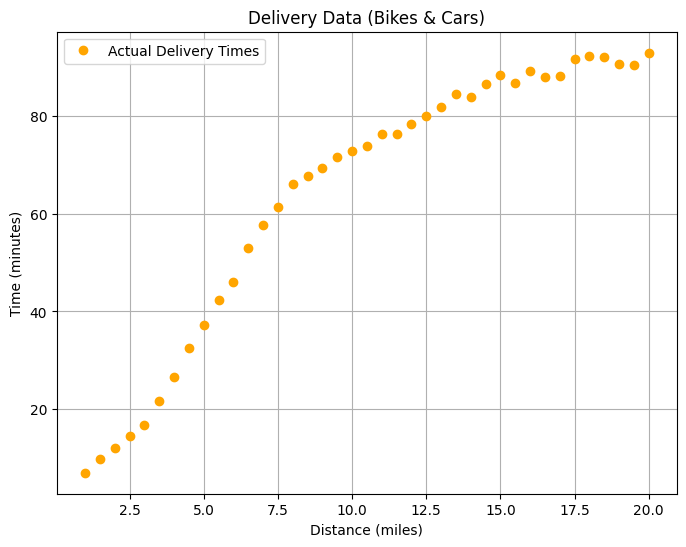

In [12]:
helper_functions.plot_data(distances,times,normalize = False)

#### *Normalizing the Data*
Before building the model, apply a quick data preparation step called __normalization__. This is a standard technique that makes the training process more stable and effective by adjusting the scale of the data. This adjustment helps prevent large distance values from dominating the learning process and keeps gradients stable during training.

Calculate the mean and standard deviation for the distances and times tensors.
Then apply standardization to each tensor using its respective mean and standard deviation, which creates new normalized tensors named distances_norm and times_norm.
This specific technique is called __standardization (or z-score normalization)__, which converts the original data from 1.0 to 20.0 miles and approximately 7 to 93 minutes into a new, normalized scale.

In [8]:
# Calculate the mean and standard deviation for the 'distances' tensor
distances_mean = distances.mean()
distances_std = distances.std()

# Calculate the mean and standard deviation for the 'times' tensor
times_mean = times.mean()
times_std = times.std()

# Apply standardization to the distances.
distances_norm = (distances - distances_mean)/ distances_std

# Apply standardization to the times.
times_norm = (times - times_mean)/ times_std


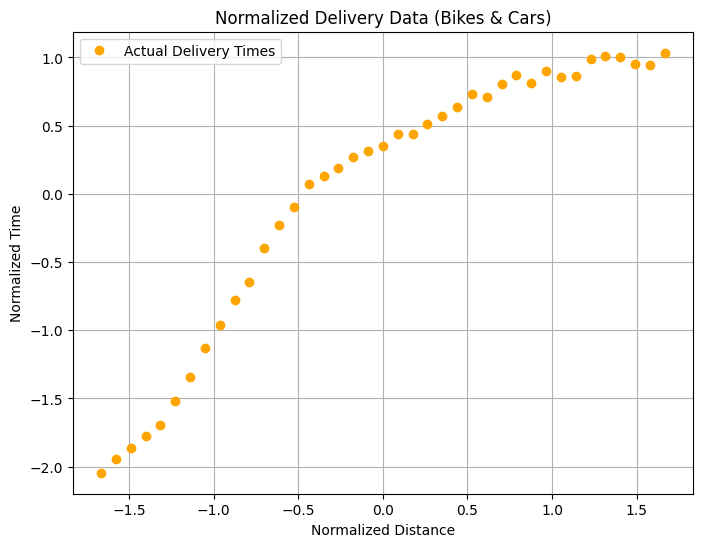

In [13]:
helper_functions.plot_data(distances_norm,times_norm,normalize = True)

Notice the axes now show the data on a new, normalized scale, with distance ranging from approximately -1.7 to 1.7 and time from -2.0 to 1.0.
Despite this change in scale, the underlying curved pattern of the data remains exactly the same.

#### *Building the Non-Linear Model*
With the normalized data ready, now build a model capable of learning its curved pattern. Define the model's architecture, which now includes a ReLU activation function. This structure is what gives model the ability to learn non-linear relationships.

* __nn.Linear(1, 3)__: This is first hidden layer. It consists of three neurons, each receiving one input feature (the normalized distance). This layer transforms the single input value into three separate values.
* __nn.ReLU()__ applies the ReLU activation function to the output of each of the three neurons from the hidden layer. This is the crucial non-linear step that allows model to create "bends" and learn curves instead of just straight lines.
* __nn.Linear(3, 1)__: This is output layer. It takes the three activated values from the previous step as its input and combines them to produce a single output, which is the predicted (normalized) delivery time.
This creates a neural network with 1 hidden layer containing 3 neurons.

In [19]:
# Create Sequential model with one hidden layer with relu activation function and one output layer
model = nn.Sequential(
    nn.Linear(1,3),
    nn.ReLU(),
    nn.Linear(3,1)
)

#### *Training*

In [22]:
# Define the loss function and optimizer for training
loss_fn = nn.MSELoss()
optimizer = optim.SGD(params = model.parameters(),lr = 0.01)

The training loop for 3000 epochs (because the non-linear pattern is more complex and requires more training). This will repeatedly feed the normalized data to the model, measure the error, and adjust the model's parameters to improve its predictions.
The second half of the code includes a live plot, allowing to watch in real time as the model's prediction line adapts to fit the curved data. The live plot helps to see how the model gradually learns to fit the curve, starting with a poor fit and improving over time.

__IMPORTANT NOTE__: As the plot updates in real time during training, notice a flickering effect. This is the expected behavior of the live visualization and not an issue with the screen.

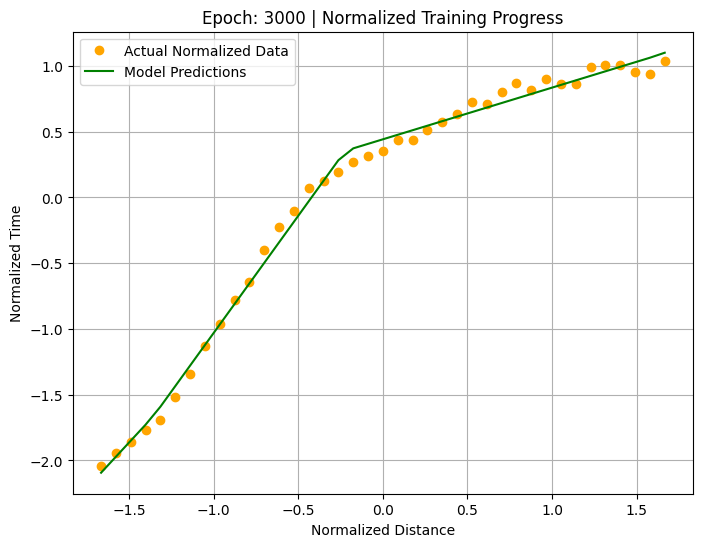


Training Complete

 Loss: 0.004653915297240019


In [31]:
# Training loop
for epoch in range(3000):
    # Reset the optimizer's gradients
    optimizer.zero_grad()
    # Make predictions (forward pass)
    output = model(distances_norm)
    # Calculate the loss
    loss = loss_fn(output,times_norm)
    # Calculate adjustments (backward pass)
    loss.backward()
    # Update the model's parameters
    optimizer.step()


    # Create a live plot every 50 epochs
    if (epoch+1)%50 == 0:
        helper_functions.plot_training_progress(
            epoch = epoch,
            model = model,
            distances_norm = distances_norm,
            times_norm = times_norm)


print("\nTraining Complete")
print(f"\n Loss: {loss.item()}")

#### *Checking the Model Fit*
Now that training is complete, visualize the result.

Plot the model's predicted curve against the original data points.
Visually inspect how well the non-linear model learned to fit the complex data pattern.

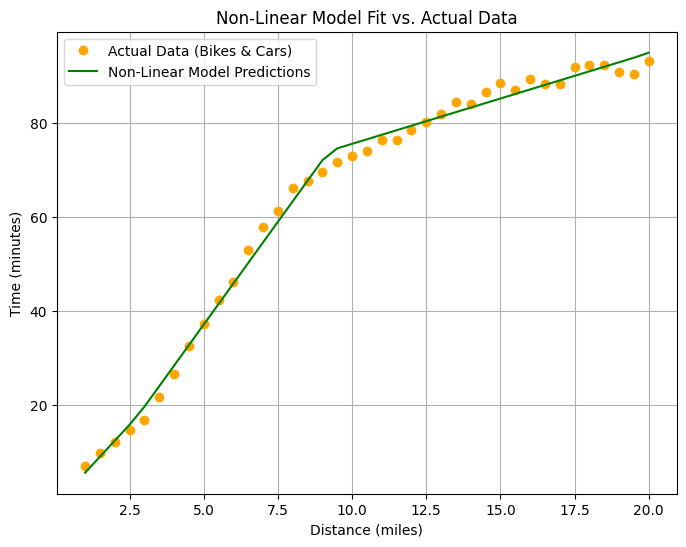

In [42]:
helper_functions.plot_model_fit(
    model = model,
    distances = distances,
    times = times,
    distances_norm = distances_norm,
    times_std = times_std,
    times_mean = times_mean)

#### *Making a Prediction*

With the fully trained non-linear model, it can be use to make a prediction for a new data. The process is slightly different because the model was trained on normalized data.

First, take the new input distance and normalize it using the same mean and standard deviation from the training data. This step is important because model has no idea about the original scales (miles and minutes). It only understands the normalized scale it was trained on.
After the model provides its prediction, de-normalize the output. This converts the prediction from its normalized scale back into an understandable value in minutes.

In [43]:
distance_to_predict = 5.1

In [44]:
# Use the torch.no_grad() context manager for efficient prediction
with torch.no_grad():
    # Normalize the input distance
    distance_tensor = torch.tensor([[distance_to_predict]],dtype = torch.float32)
    distance_norm = (distance_tensor - distances_mean)/distances_std

    # Get the normalized prediction from the model
    predicted_norm = model(distance_norm)

    # De-normalize the output to get the actual time in minutes
    predicted = (predicted_norm * times_std) + times_mean

    print(f"Prediction for a {distance_to_predict} mile delivery: {predicted.item():.1f} minutes")

Prediction for a 5.1 mile delivery: 37.9 minutes
